# 020 - Covariance Analysis 

## 1.00 Admin  

#### 1.10 Libraries

In [1]:
from qiskit import (
    QuantumCircuit, 
    transpile,
)
from qiskit_ibm_runtime import (
    Batch,
    SamplerV2,
    QiskitRuntimeService,
)

# for circuit graphics 
import pylatexenc

# for the environment report 
# import environment as envir 
from tabulate import tabulate 


ModuleNotFoundError: No module named 'qiskit_ibm_runtime'

#### 1.10 Environment 

In [2]:
data, headers = envir.environment_state()
print(tabulate(data, headers=headers, tablefmt="grid"))

+-------------------------+-----------+
| System/Library          | Version   |
+=========================+===========+
| Python                  | 3.11.15   |
+-------------------------+-----------+
| numpy                   | 2.4.3     |
+-------------------------+-----------+
| torch                   | 2.10.0    |
+-------------------------+-----------+
| matplotlib              | 3.10.8    |
+-------------------------+-----------+
| seaborn                 | 0.13.2    |
+-------------------------+-----------+
| qiskit                  | 2.2.0     |
+-------------------------+-----------+
| qiskit_machine_learning | 0.9.0     |
+-------------------------+-----------+
| qiskit_optimization     | 0.7.0     |
+-------------------------+-----------+
| qiskit_ibm_runtime      | 0.45.1    |
+-------------------------+-----------+
| pylatexenc              | 2.10      |
+-------------------------+-----------+
| qiskit_algorithms       | 0.4.0     |
+-------------------------+-----------+


#### 1.20 Notebook Parameters 

In [3]:
n_qubits = 8 

print_flag = True 

#### 1.30 Platform Authentication

In [4]:
service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    instance="ptc_work", 
)

#### 1.40 Backend Selection (Least Busy) 

In [5]:
# Filter for real devices (exclude simulators) and those that are operational
backends = service.backends(
    simulator=False,
    operational=True
)

# Sort by queue length
least_busy = sorted(backends, key=lambda b: b.status().pending_jobs)[0]

backend = least_busy
print(f"Using least busy backend: {backend.name}")
print(f"Pending jobs: {backend.status().pending_jobs}")

Using least busy backend: ibm_fez
Pending jobs: 0


### 2.00 Circuit Build 

#### 2.10 Raw Circuit Buld 

Circuit Created


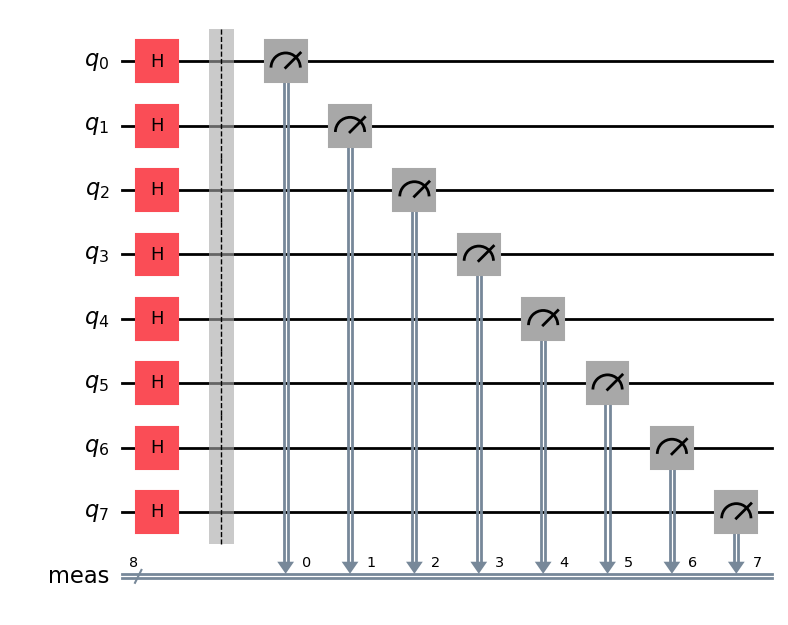

In [6]:
# create a Bell circuit
qc = QuantumCircuit(n_qubits)
for i in range(n_qubits):
    qc.h(i)

qc.measure_all()

print("Circuit Created")
qc.draw('mpl')

#### 2.20 Transpile Circuit for backend 

Optimized Circuit Created


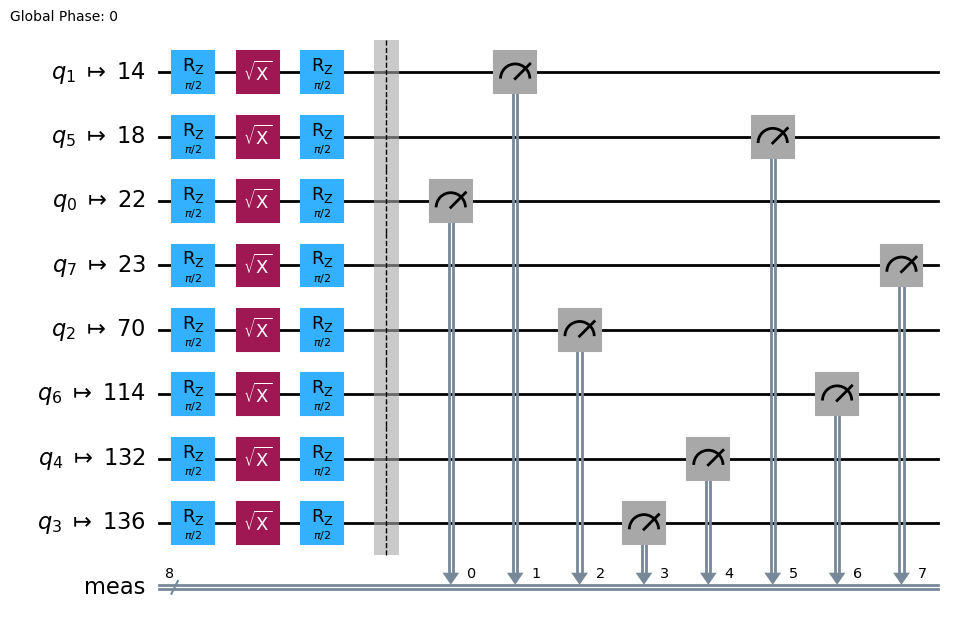

In [7]:
transpiled_circuit = transpile(qc, backend=backend)

#construct  pub 
pub_qc_measurement = (transpiled_circuit) 

print("Optimized Circuit Created")
transpiled_circuit.draw('mpl')

### 3.00 Job Submission 

#### 3.10 Assign primitive and submit job 

# Inaitialize the sampler

In [8]:
sampler = SamplerV2(backend)
job_qc_measurement = sampler.run([pub_qc_measurement], shots=1500)

In [9]:
# ------------------------------
#  6. Extract results
# ------------------------------

result_qc_measurement = job_qc_measurement.result()
data_qc_measurement = result_qc_measurement[0].data
print("qc Measurement Results:")
print(data_qc_measurement)

qc Measurement Results:
DataBin(meas=BitArray(<shape=(), num_shots=1500, num_bits=8>))


In [10]:
# -----------------------------
#  7. Post Processing 
# -----------------------------

bits = data_qc_measurement.meas
print('Shape: ', bits.shape)
print('num bits: ', bits.num_bits)
print('num shots: ', bits.num_shots)
print("array:\n", bits.array)

Shape:  ()
num bits:  8
num shots:  1500
array:
 [[228]
 [227]
 [224]
 ...
 [ 32]
 [ 73]
 [204]]


In [11]:
# ----------------------------
#  7.1. Print output 
# ----------------------------

bitstrings = bits.get_bitstrings()
print("Bitstrings:", bitstrings)

Bitstrings: ['11100100', '11100011', '11100000', '01001000', '11111001', '00111101', '01000110', '01111010', '01101001', '01001001', '11100100', '10011111', '01101010', '00110110', '10110001', '11111101', '10101011', '01110100', '10101001', '00101011', '00011100', '01011100', '11100111', '10100000', '10010101', '01110000', '10001010', '00110001', '00001010', '11101010', '10000110', '10110110', '11010100', '11110101', '10110011', '11000111', '11011000', '10101111', '10010011', '00001010', '11001110', '00000011', '10111101', '10011001', '00110101', '10100010', '01000001', '10010110', '00110001', '01101001', '01000111', '01001010', '01100110', '01110111', '10001001', '11111110', '01011010', '01000001', '01000001', '01011101', '00101110', '10101001', '01001111', '10110100', '10110011', '01101110', '11101000', '11110110', '10110101', '11000000', '10101010', '10000000', '10011100', '10101000', '11101011', '10010010', '00001000', '11011011', '10111000', '00111001', '00000101', '00011110', '10